# Useful helper function for the exam in 02601 - Introduction to Numerical Algorithms

In [104]:
import numpy as np
from sympy import *
import matplotlib.pyplot as plt

## Error

### Absolute and relative error

In [105]:
def absolute_error(approx,exact):
    return np.abs(approx - exact)

def relative_error(approx,exact):
    return absolute_error(approx,exact) / np.abs(exact)

### Sensitivity analysis

In [106]:
def sensitivity_bound(A, b, btilde, relative=True, order = 2):
    db = btilde - b

    if relative:
        kappa = np.linalg.cond(A, order)
        return kappa * np.linalg.norm(db, order) / np.linalg.norm(b, order)
    else:
        Ainv_norm = np.linalg.norm(np.linalg.inv(A), order)
        return Ainv_norm * np.linalg.norm(db, order)

#Example
A = np.array([
    [3.1,-1.2,2.6],
    [1.5,-0.7,3.6],
    [-4.1,1.1,0.7]
])
b = np.array([0.654,0.765,-1.042])
btilde = np.array([0.657, 0.761, -1.039])
sensitivity_bound(A,b,btilde)


np.float64(0.2828325384957113)

## Data fitting

Normal equation:
$$
A^T A x = A^T b
$$

In [113]:
def display_normal_eq(x,y,b):
    x = np.array(x); y = np.array(y); b = np.array(b)
    A = np.array(x,np,ones(len(x))).T
    print("A.T A b:")
    print(A.T*A * x)
    print("A.T b:")
    print(A.T * b)


Least squares fit is found to be: F(x) = 0.0751exp(-x) + 2.1572exp(-2x)


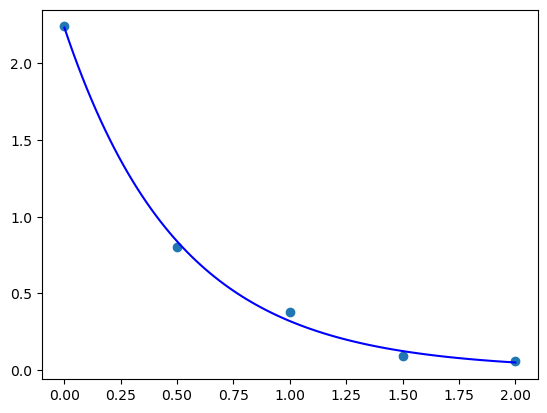

In [ ]:
def normal_eq(x, y, basis):
    A = np.array(basis(x)).T
    c = np.linalg.solve(A.T @ A, A.T @ y)

    xx = np.linspace(x.min(), x.max(), 200)
    Axx = np.array(basis(xx)).T
    yy = Axx @ c
    return (xx, yy), c


basis = lambda n: [np.ones_like(n), -np.log(n)]


fit, c = normal_eq(x,y, basis)
print("c:",c)
plt.plot(x,y,'o', fit[0], fit[1], '-b')

## Interpolation

### Symbolic

In [85]:
def s_lambdapoly(xi,xj,x):
    return (x - xj) / (xi - xj)

def s_initiate_notes(n, symbol = 'x', start_index = 0):
    s = start_index
    x = {i : symbols(f"{symbol}{i}") for i in range(s,n + s)} 

    return x


# x = s_initiate_notes(4,1)
# display(s_lambdapoly(x[1],x[2],1))

def s_cardinalpoly(i: int, variables: dict|tuple, x = symbols("x")):
    """
    For variables == tuple: variables = (n, symbol, start_inx).

    This is used for when the function acts as a standalone
    """
    if type(variables) == tuple:
        variables = s_initiate_notes(n = variables[0], symbol=variables[1], start_index=variables[2])
    l_i = 1
    for j in variables:
        if j != i and type(j):
            l_i *= s_lambdapoly(variables[i],variables[j],x)

    return l_i


def s_lagrangepoly(n: int, start_index: int, x = symbols('x')):
    s = start_index
    data = {'x': s_initiate_notes(n, 'x', s), 'y': s_initiate_notes(n, 'y', s)}
    
    p = sum([s_cardinalpoly(i, data['x']) * data['y'][i] for i in range(s, n + s)])

    return p

s_lagrangepoly(n = 4, start_index=1, x = symbols('x'))

y1*(x - x2)*(x - x3)*(x - x4)/((x1 - x2)*(x1 - x3)*(x1 - x4)) + y2*(x - x1)*(x - x3)*(x - x4)/((-x1 + x2)*(x2 - x3)*(x2 - x4)) + y3*(x - x1)*(x - x2)*(x - x4)/((-x1 + x3)*(-x2 + x3)*(x3 - x4)) + y4*(x - x1)*(x - x2)*(x - x3)/((-x1 + x4)*(-x2 + x4)*(-x3 + x4))

## Time analysis

In [ ]:
def time_analysis(n: int, n_init: int, t_init: float, system_complexities: list):
    ops_init = 0
    ops = 0
    for s in system_complexities:
        ops_init += s(n_init)
        ops += s(n)
    time_per_op = t_init / ops_init
    time = ops * time_per_op

    return time

print(time_analysis(800, 200, 0.36, [lambda n: 1/3 * n**3, lambda n: n**2]))

22.78463054187192


## Integration

In [ ]:
def MySimpson(f, a, b, n):

    if n % 2:
        print("n must be even")
        return float("nan")
    h = (b - a) / n
    f_evaluations = [f(a + i * h) for i in range(n + 1)]
    
    for i in range(1, n, 2):
        f_evaluations[i] *= 4
    for i in range(2, n-1, 2):
        f_evaluations[i] *= 2
    
    return h / 3 * sum(f_evaluations)